
Training PINN + HPM model...
Epoch 0: Train Loss = 0.084087, Val Loss = 0.117968
Epoch 50: Train Loss = 0.009042, Val Loss = 0.008717
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train R2: 0.9935, Accuracy: 99.35%, Test R2: 0.9919, Accuracy: 99.19%

Training PINN + SPBA model...
Epoch 0: Train Loss = 0.106050, Val Loss = 0.139166
Epoch 50: Train Loss = 0.008624, Val Loss = 0.014999
Epoch 100: Train Loss = 0.008445, Val Loss = 0.007474
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Train R2: 0.9844, Accuracy: 98.44%, Test R2: 0.9816, Accuracy: 98.16%

Training PINN + CPSA model...
Epoch 0: Train Loss = 0.087862, Val Loss = 0.172461
Epoch 50: Train Loss = 0.008833, Val Loss = 0.022882
Epoch 100: Train Loss = 0.008765, Val Loss = 0.026566
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train R2: 0.9913, Accuracy: 99.13

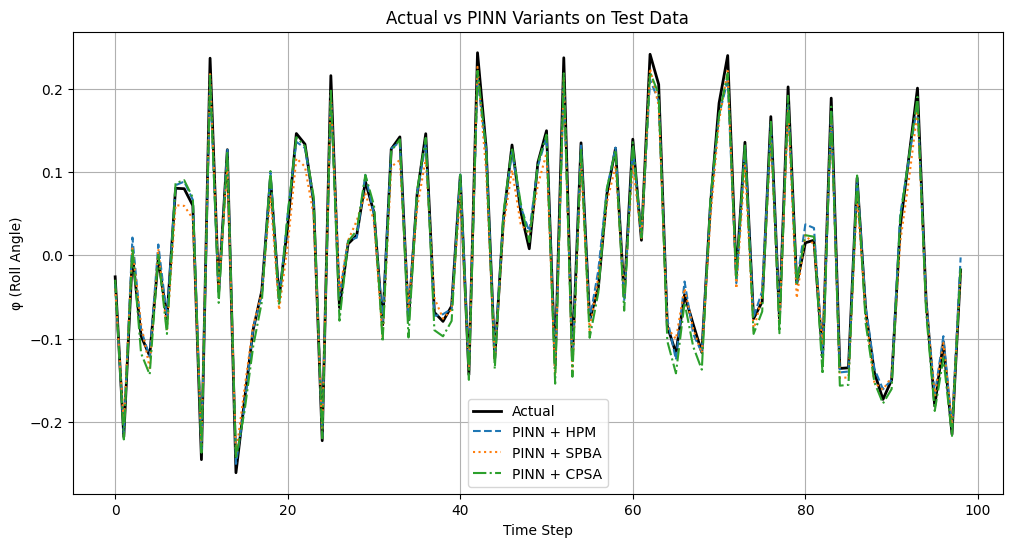

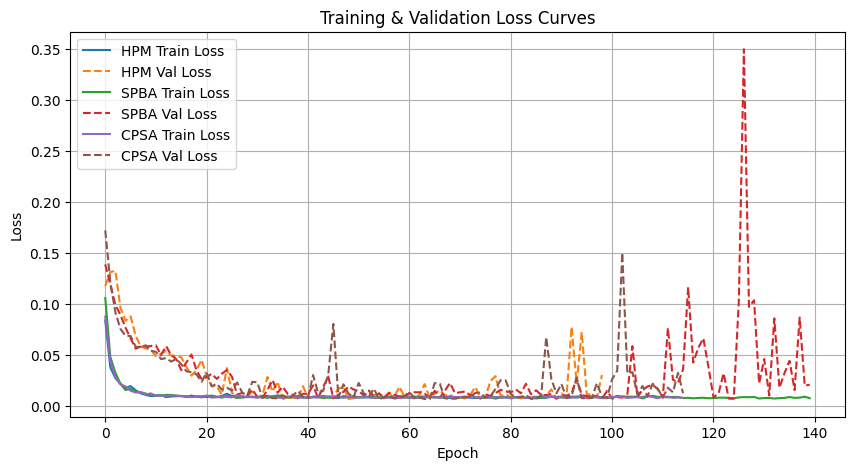

In [ ]:
# ============================================
# Imports
# ============================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# ============================================
# Reproducibility
# ============================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# Load Dataset
# ============================================
df = pd.read_csv("/content/roll_motion_table2_1000.csv", header=None, skiprows=1)
df.columns = ["Time(s)", "phi", "phi_dot"]

X = df[['Time(s)', 'phi', 'phi_dot']].values
y = df['phi'].values.reshape(-1, 1)

# ============================================
# Normalization
# ============================================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ============================================
# Create Sequences
# ============================================
def create_sequences(X, y, lookback=16):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

lookback = 16
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)

# Split into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.2, random_state=SEED, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, shuffle=True)

# ============================================
# Physics Constants
# ============================================
zeta = 0.05
omega_n = 0.8

# ============================================
# Build LSTM PINN Model
# ============================================
def build_model():
    input_layer = Input(shape=(lookback, X_train.shape[2]))
    x = LSTM(256, return_sequences=True)(input_layer)
    x = LSTM(128)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)
    model = Model(inputs=input_layer, outputs=output)
    return model

# ============================================
# Physics Residuals
# ============================================
@tf.function
def residual_hpm(x_batch, y_pred):
    phi_dot_seq = x_batch[:, -1:, 2:3]  # last φ̇
    phi_ddot_approx = phi_dot_seq - x_batch[:, -2:-1, 2:3]  # finite diff
    phi_t = y_pred
    phi_dot_t = phi_dot_seq
    return tf.squeeze(phi_ddot_approx + 2*zeta*omega_n*phi_dot_t + (omega_n**2)*phi_t, axis=-1)

@tf.function
def residual_spba(x_batch, y_pred):
    # simple variation: weighted difference
    phi_dot_seq = x_batch[:, -1:, 2:3]
    phi_ddot_approx = 0.5*(phi_dot_seq - x_batch[:, -2:-1, 2:3])
    phi_t = y_pred
    phi_dot_t = phi_dot_seq
    return tf.squeeze(phi_ddot_approx + 2*zeta*omega_n*phi_dot_t + (omega_n**2)*phi_t, axis=-1)

@tf.function
def residual_cpsa(x_batch, y_pred):
    # simple variant using mean of last 3 steps
    phi_dot_seq = x_batch[:, -3:, 2:3]
    phi_ddot_approx = tf.reduce_mean(phi_dot_seq[:, 1:, :] - phi_dot_seq[:, :-1, :], axis=1)
    phi_t = y_pred
    phi_dot_t = phi_dot_seq[:, -1:, :]
    return tf.squeeze(phi_ddot_approx + 2*zeta*omega_n*phi_dot_t + (omega_n**2)*phi_t, axis=-1)

# ============================================
# PINN Loss with Residual Variant
# ============================================
def pinn_loss(y_true, y_pred, x_batch, method='hpm', lambda_phys=0.05):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    if method == 'hpm':
        res = residual_hpm(x_batch, y_pred)
    elif method == 'spba':
        res = residual_spba(x_batch, y_pred)
    else:  # cpsa
        res = residual_cpsa(x_batch, y_pred)
    phys_loss = tf.reduce_mean(tf.square(res))
    return mse + lambda_phys * phys_loss

# ============================================
# Training Function
# ============================================
def train_model(model, X_train, y_train, X_val, y_val, method='hpm',
                epochs=600, batch_size=32, patience=50, lambda_phys=0.05):

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    best_val_loss = np.inf
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        idx = np.random.permutation(len(X_train))
        X_train, y_train = X_train[idx], y_train[idx]
        batch_losses = []

        for i in range(0, len(X_train), batch_size):
            x_batch = tf.convert_to_tensor(X_train[i:i+batch_size], tf.float32)
            y_batch = tf.convert_to_tensor(y_train[i:i+batch_size], tf.float32)

            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                loss = pinn_loss(y_batch, y_pred, x_batch, method, lambda_phys)
            grads = tape.gradient(loss, model.trainable_variables)
            grads = [tf.clip_by_norm(g, 1.0) for g in grads]
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            batch_losses.append(loss.numpy())

        train_loss = np.mean(batch_losses)
        val_loss = pinn_loss(tf.convert_to_tensor(y_val, tf.float32),
                             model(tf.convert_to_tensor(X_val, tf.float32), training=False),
                             tf.convert_to_tensor(X_val, tf.float32),
                             method, lambda_phys).numpy()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_weights = model.get_weights()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                model.set_weights(best_weights)
                break

    return train_losses, val_losses

# ============================================
# Evaluation Function
# ============================================
def evaluate(model, X, y, scaler):
    y_pred = model.predict(X)
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_true_inv = scaler.inverse_transform(y)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)
    return y_true_inv, y_pred_inv, rmse, mae, r2, r2*100

# ============================================
# Train All PINN Variants
# ============================================
methods = ['hpm', 'spba', 'cpsa']
models = {}
results = {}
loss_histories = {}

for method in methods:
    print(f"\nTraining PINN + {method.upper()} model...")
    model = build_model()
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val, method, lambda_phys=0.05)
    y_train_true, y_train_pred, tr_rmse, tr_mae, tr_r2, tr_acc = evaluate(model, X_train, y_train, scaler_y)
    y_test_true, y_test_pred, ts_rmse, ts_mae, ts_r2, ts_acc = evaluate(model, X_test, y_test, scaler_y)
    print(f"Train R2: {tr_r2:.4f}, Accuracy: {tr_acc:.2f}%, Test R2: {ts_r2:.4f}, Accuracy: {ts_acc:.2f}%")

    models[method] = model
    results[method] = (y_test_true, y_test_pred)
    loss_histories[method] = (train_losses, val_losses)

# ============================================
# Plot predictions
# ============================================
plt.figure(figsize=(12, 6))
plt.plot(results['hpm'][0], label='Actual', color='black', linewidth=2)
plt.plot(results['hpm'][1], label='PINN + HPM', linestyle='dashed')
plt.plot(results['spba'][1], label='PINN + SPBA', linestyle='dotted')
plt.plot(results['cpsa'][1], label='PINN + CPSA', linestyle='dashdot')
plt.title('Actual vs PINN Variants on Test Data')
plt.xlabel('Time Step')
plt.ylabel('φ (Roll Angle)')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# Plot loss curves
# ============================================
plt.figure(figsize=(10, 5))
for key, (train_loss, val_loss) in loss_histories.items():
    plt.plot(train_loss, label=f'{key.upper()} Train Loss')
    plt.plot(val_loss, label=f'{key.upper()} Val Loss', linestyle='dashed')
plt.title('Training & Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================
# Overfitting Check
# ============================================

def overfitting_check(models, X_train, y_train, X_test, y_test, scaler_y):
    print("\n=== Overfitting Check ===")
    for method, model in models.items():
        # Train evaluation
        _, _, tr_rmse, tr_mae, tr_r2, tr_acc = evaluate(model, X_train, y_train, scaler_y)
        # Test evaluation
        _, _, ts_rmse, ts_mae, ts_r2, ts_acc = evaluate(model, X_test, y_test, scaler_y)

        print(f"\nMethod: {method.upper()}")
        print(f"Train → RMSE: {tr_rmse:.4f}, MAE: {tr_mae:.4f}, R²: {tr_r2:.4f}, Accuracy: {tr_acc:.2f}%")
        print(f"Test  → RMSE: {ts_rmse:.4f}, MAE: {ts_mae:.4f}, R²: {ts_r2:.4f}, Accuracy: {ts_acc:.2f}%")

        if tr_r2 - ts_r2 > 0.15:  # gap threshold
            print("Possible Overfitting: Large gap between train and test performance.")
        else:
            print("Generalization looks reasonable.")

overfitting_check(models, X_train, y_train, X_test, y_test, scaler_y)



=== Overfitting Check ===
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Method: HPM
Train → RMSE: 0.0106, MAE: 0.0079, R²: 0.9935, Accuracy: 99.35%
Test  → RMSE: 0.0114, MAE: 0.0085, R²: 0.9919, Accuracy: 99.19%
Generalization looks reasonable.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Method: SPBA
Train → RMSE: 0.0165, MAE: 0.0146, R²: 0.9844, Accuracy: 98.44%
Test  → RMSE: 0.0172, MAE: 0.0151, R²: 0.9816, Accuracy: 98.16%
Generalization looks reasonable.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Method: CPSA
Train → RMSE: 0.0123, MAE: 0.0100, R²: 0.9913, Accuracy: 99.13%
Test  → RMSE: 0.0131, MAE: 0.0109, R²: 0.9894, Accuracy: 98.94%
Generalization looks reasonable.
